# Reverse Diffusion — Sample Generation Pipeline

Generates synthetic time-series samples from a trained CSDI checkpoint and saves them to `data/generated/toy/` in the same CSV + stats-pickle format expected by `Toy_dataset_analysis.ipynb`.

**To use in the analysis notebook** update its path variables:
```python
gen_dir       = "../data/generated/toy/"
gen_stats_path = "../data/generated/toy/fake_stats_generated.pkl"
```

## 1. Imports

In [8]:
import os
import sys
import pickle
import warnings
warnings.filterwarnings("ignore")
import json

import numpy as np
import pandas as pd
import torch
import yaml
from copy import deepcopy

# Make project root importable from the notebooks/ folder
sys.path.insert(0, os.path.abspath(".."))

from src.models.model_core import CSDIModel
from src.utils.WIP_processes import Diffusion_Processes

## 2. Parameters

Edit the three variables below before running the rest of the notebook.

In [9]:
# ── Checkpoint ────────────────────────────────────────────────────────────────
# Name of the .pt file inside  checkpoints/csdi/
CHECKPOINT_FOLDER = "toy"
CHECKPOINT_NAME = "FAKE_CLOS_final_ep-30_step-92160_sde-vp_lr-1e-04_N-1000_notlinear_layers-4_nheads-8_20260322_103627.pt"

# ── Mask mode ─────────────────────────────────────────────────────────────────
# "unconditional"  → generate all OHLCV features from pure noise
# "predict_close"  → condition on observed O, H, L, V and predict C only
mask_mode = "predict_close"

# ── Generation ────────────────────────────────────────────────────────────────
N_SAMPLES = 100       # number of synthetic time-series to generate

# ── Conditioning dataset (used only when mask_mode == "predict_close") ────────
# Path to a folder containing processed CSV files with columns:
#   Date, Open, High, Low, Close, Volume
# This should be the same dataset used for training.
# N_SAMPLES CSV files will be picked (alphabetically) from this directory.
COND_DATA_DIR = os.path.join("..", "data", "fake_individual_gbm")

# Optional path to a stats pickle {ticker: {"mean": np.array(K,), "std": np.array(K,)}}
# produced during training.  Set to None to compute z-score stats on the fly
# from each individual series.
COND_STATS_PATH = None   # e.g. os.path.join("..", "data", "fake_individual_gbm", "fake_stats.pkl")

# ── Time horizon ──────────────────────────────────────────────────────────────
# Each generated sample gets a *random* start date drawn uniformly from
# [START_DATE,  END_DATE - YEARS_PER_SAMPLE years].
# The date index then spans exactly YEARS_PER_SAMPLE years of business days
# from that random start (truncated to seq_len rows to match the model output).
START_DATE      = "1986-01-01"   # earliest possible start date for any sample
END_DATE        = "2025-12-31"   # latest possible end date  for any sample
YEARS_PER_SAMPLE = 1             # how many years of business days each sample covers

# ── Optional: override the number of reverse diffusion steps ──────────────────
# None  → use the value stored in the checkpoint config (process.N, typically 1000)
# int   → e.g. 200 for a faster (lower quality) run
NUM_REVERSE_STEPS = 200

# ── Output folder ─────────────────────────────────────────────────────────────
# Samples are saved under  data/generated/<CHECKPOINT_FOLDER>/<RUN_TAG>/
# Default: the checkpoint stem (without .pt), so each model gets its own folder.
# Override with any short string to group related runs together.
RUN_TAG = os.path.splitext(CHECKPOINT_NAME)[0]   # e.g. "FAKE_CLOS_final_ep-30_..."

## 3. Load checkpoint and instantiate model

In [10]:
CHECKPOINT_PATH = os.path.join("..", "checkpoints", CHECKPOINT_FOLDER, CHECKPOINT_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ckpt   = torch.load(CHECKPOINT_PATH, map_location=device)
config = ckpt["config"]

# Full config (everything)
print(json.dumps(ckpt["run_metadata"], indent=2))


target_dim = int(config["data"]["target_dim"])   # K = 5 features
seq_len    = int(config["train"]["seq_len"])      # L = 252 time steps

model = CSDIModel(target_dim=target_dim, config=config, device=device).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

print(f"Checkpoint : {CHECKPOINT_NAME}")
print(f"target_dim : {target_dim}  |  seq_len : {seq_len}")
print(f"SDE type   : {config['process']['sde_type']}")

Device: cpu
{
  "train": {
    "seed": 42,
    "epochs": 30,
    "batch_size": 32,
    "lr": 0.0001,
    "weight_decay": 0.0001,
    "use_amp": true,
    "cond_min_ratio": 0.1,
    "cond_max_ratio": 0.9,
    "mask_mode": "predict_close",
    "seq_len": 252,
    "stride": 10
  },
  "process": {
    "sde_type": "vp",
    "N": 1000,
    "model_steps": 50,
    "eps": 0.001,
    "enforce_observed": true
  },
  "diffusion": {
    "num_steps": 50,
    "diffusion_embedding_dim": 128,
    "channels": 64,
    "layers": 4,
    "nheads": 8,
    "is_linear": false
  },
  "model": {
    "timeemb": 128,
    "featureemb": 64,
    "is_unconditional": false
  },
  "data": {
    "target_dim": 5
  }
}
Checkpoint : FAKE_CLOS_final_ep-30_step-92160_sde-vp_lr-1e-04_N-1000_notlinear_layers-4_nheads-8_20260322_103627.pt
target_dim : 5  |  seq_len : 252
SDE type   : vp


## 4. Instantiate Diffusion_Processes

In [11]:
processes = Diffusion_Processes(config["process"])

num_reverse_steps = NUM_REVERSE_STEPS if NUM_REVERSE_STEPS is not None else processes.N
print(f"Diffusion_Processes ready — SDE: {processes.sde_type}, N: {processes.N}, model_steps: {processes.model_steps}")
print(f"Reverse steps to use: {num_reverse_steps}")

Diffusion_Processes ready — SDE: vp, N: 1000, model_steps: 50
Reverse steps to use: 200


## 5. Build conditioning tensors and generate samples

**`mask_mode = "unconditional"`** — `cond_mask = 0` everywhere; the model receives no context and generates all OHLCV features from pure noise.

**`mask_mode = "predict_close"`** — Open, High, Low and Volume are loaded from `COND_DATA_DIR`, z-score normalise

## 5. Generate samples

We generate unconditionally: `cond_mask = 0` everywhere so the model receives no context a

In [12]:
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
CLOSE_IDX    = FEATURE_COLS.index("Close")               # 3
COND_INDICES = [i for i, f in enumerate(FEATURE_COLS) if f != "Close"]  # [0,1,2,4]

# Normalisation stats used to rescale conditioning data back to the original space
# after generation (filled in the predict_close branch; None in unconditional mode).
norm_stats = {}   # {sample_idx: {"mean": (K,), "std": (K,), "ticker": str}}

# ── Build observed_data and cond_mask ─────────────────────────────────────────
if mask_mode == "unconditional":
    observed_data = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
    cond_mask     = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
    cond_tickers  = [f"FAKE_{i+1:04d}" for i in range(N_SAMPLES)]

elif mask_mode == "predict_close":
    csv_files = sorted([f for f in os.listdir(COND_DATA_DIR) if f.endswith(".csv")])
    if len(csv_files) < N_SAMPLES:
        raise ValueError(
            f"Need {N_SAMPLES} CSV files but found only {len(csv_files)} in {COND_DATA_DIR}"
        )
    selected_files = csv_files[:N_SAMPLES]

    # Load optional pre-computed stats pickle
    precomp_stats = {}
    if COND_STATS_PATH is not None:
        with open(COND_STATS_PATH, "rb") as f:
            precomp_stats = pickle.load(f)

    obs_np    = np.zeros((N_SAMPLES, target_dim, seq_len), dtype=np.float32)
    cond_tickers = []

    for idx, fname in enumerate(selected_files):
        ticker = fname.split("_processed")[0]   # best-effort ticker name
        cond_tickers.append(ticker)

        df   = pd.read_csv(os.path.join(COND_DATA_DIR, fname))
        vals = df[FEATURE_COLS].values[:seq_len].T.astype(np.float32)  # (K, L)

        # z-score normalisation — use pre-computed stats if available, else per-series
        if ticker in precomp_stats:
            mu  = precomp_stats[ticker]["mean"].reshape(-1, 1)   # (K, 1)
            std = precomp_stats[ticker]["std"].reshape(-1, 1)
        else:
            mu  = vals.mean(axis=1, keepdims=True)
            std = vals.std(axis=1, keepdims=True).clip(min=1e-8)

        norm_stats[idx] = {"mean": mu.squeeze(), "std": std.squeeze(), "ticker": ticker}
        obs_np[idx] = (vals - mu) / std

    observed_data = torch.from_numpy(obs_np).to(device)

    # cond_mask: 1 = observed (O, H, L, V), 0 = to predict (Close)
    cond_mask = torch.zeros(N_SAMPLES, target_dim, seq_len, device=device)
    cond_mask[:, COND_INDICES, :] = 1.0

else:
    raise ValueError(f"Unknown mask_mode: {mask_mode!r}. Choose 'unconditional' or 'predict_close'.")

print(f"mask_mode     : {mask_mode}")
print(f"observed frac : {cond_mask.mean().item():.2f}  (fraction of observed values)")

mask_mode     : predict_close
observed frac : 0.80  (fraction of observed values)


This is our SDE: <src.utils.WIP_SDE.VPSDE object at 0x000002A90CC98B90>
This is the value of T: 1.0
Check prior vp: Mean = -0.0026599352713674307, Std = 1.000707983970642
[step    1/200 | t=1.0000]  mean=-0.0036  std=1.0068  min=-4.6423  max=4.6553  dx_norm=3.18e-05
  per-feat std: k0=1.015  k1=1.006  k2=1.010  k3=0.989  k4=1.014
  elapsed 3.9s

[step    2/200 | t=0.9950]  mean=-0.0046  std=1.0232  min=-4.5849  max=4.6930  dx_norm=3.98e-04
  per-feat std: k0=1.035  k1=1.026  k2=1.031  k3=0.991  k4=1.033
  elapsed 3.5s

[step    3/200 | t=0.9900]  mean=-0.0055  std=1.0394  min=-4.7982  max=4.7328  dx_norm=3.98e-04
  per-feat std: k0=1.054  k1=1.046  k2=1.051  k3=0.991  k4=1.053
  elapsed 3.3s

[step    4/200 | t=0.9849]  mean=-0.0070  std=1.0554  min=-4.6944  max=4.7862  dx_norm=3.97e-04
  per-feat std: k0=1.073  k1=1.065  k2=1.071  k3=0.992  k4=1.073
  elapsed 3.4s

[step    5/200 | t=0.9799]  mean=-0.0090  std=1.0713  min=-4.5979  max=4.6937  dx_norm=3.96e-04
  per-feat std: k0=1.092 

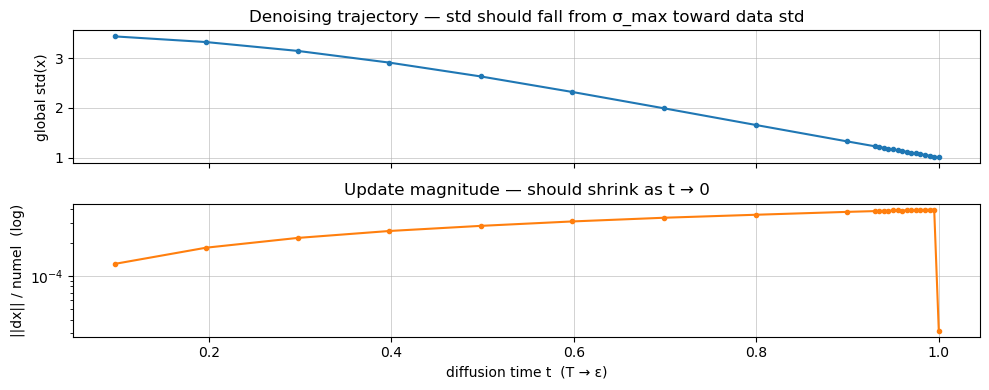

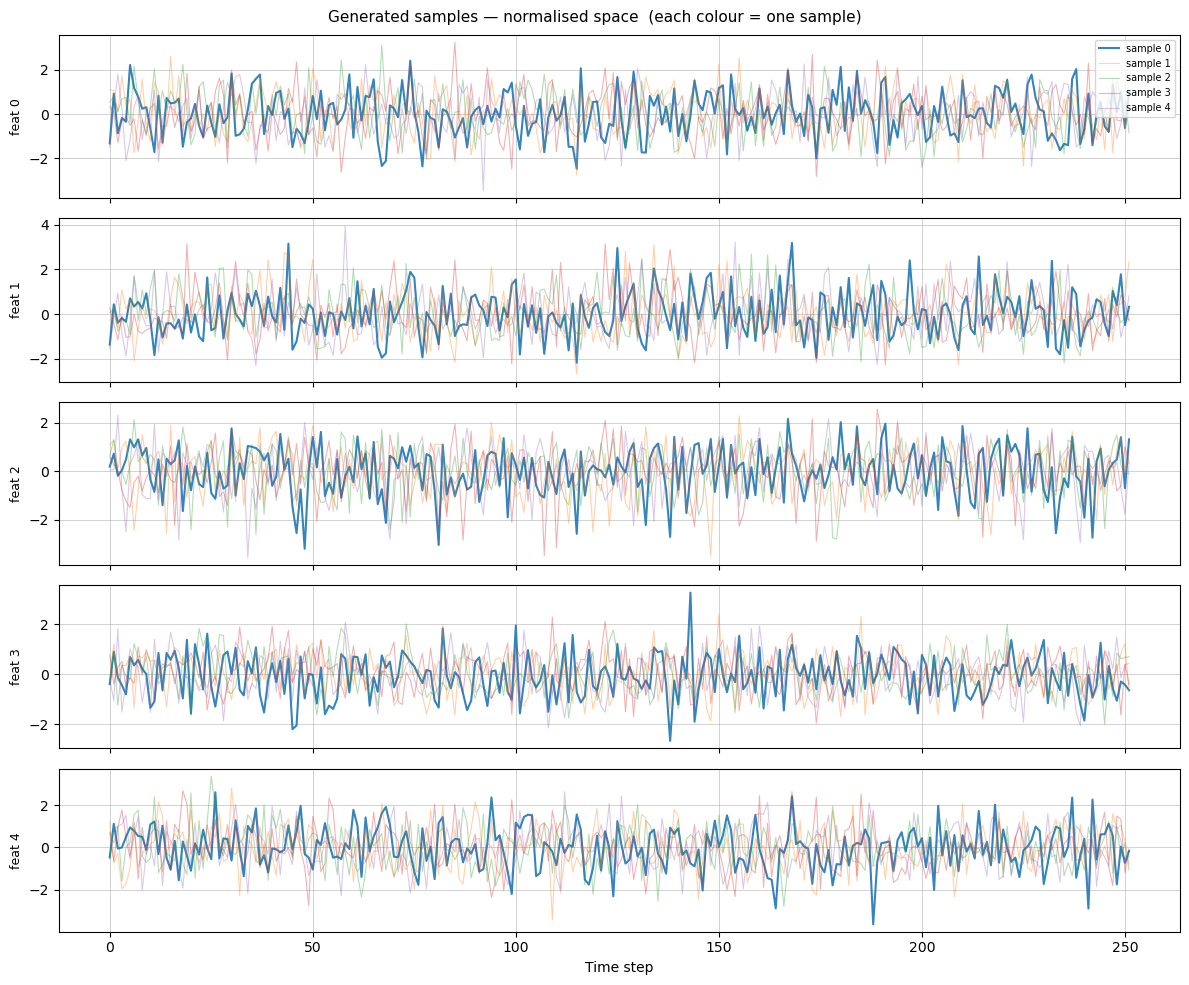


Generated tensor shape : torch.Size([100, 5, 252])
Mean  : 0.0009
Std   : 0.9661
Range : [-5.4659, 5.4135]


In [13]:
# ── Normalised time positions ─────────────────────────────────────────────────
observed_tp = torch.linspace(0.0, 1.0, seq_len, device=device).unsqueeze(0).expand(N_SAMPLES, -1)

# ── Run reverse diffusion ─────────────────────────────────────────────────────
samples = processes.reverse_process(
    model            = model,
    shape            = (N_SAMPLES, target_dim, seq_len),
    observed_data    = observed_data,
    cond_mask        = cond_mask,
    observed_tp      = observed_tp,
    num_steps        = num_reverse_steps,
    probability_flow = False,
    device           = device,
)  # → (N_SAMPLES, K, L)

print(f"\nGenerated tensor shape : {samples.shape}")
print(f"Mean  : {samples.mean().item():.4f}")
print(f"Std   : {samples.std().item():.4f}")
print(f"Range : [{samples.min().item():.4f}, {samples.max().item():.4f}]")

## 6. Save results to `data/generated/toy/`

**Unconditional mode** — each sample is saved as a separate CSV (`FAKE_XXXX_<start>_<end>_processed.csv`) with columns `Date, Open, High, Low, Close, Volume` (all model-generated).

**`predict_close` mode** — the CSV contains the *original* O, H, L, V values (from `COND_DATA_DIR`, denormalised) and the *model-predicted* Close (denormalised).  The output filename uses the source ticker name so results can be matched back to the input.

In both cases a companion `fake_stats_generated.pkl` stores per-ticker `{"mean": ..., "std": ...}` (in original d

In [14]:
OUT_DIR = os.path.join("..", "data", "generated", CHECKPOINT_FOLDER, RUN_TAG)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Build the pool of valid random start dates ────────────────────────────────
# A valid start date is one where start + YEARS_PER_SAMPLE years still falls
# before END_DATE, so the full date range is contained within the window.
from dateutil.relativedelta import relativedelta

all_bdays   = pd.bdate_range(start=START_DATE, end=END_DATE)
cutoff_date = pd.Timestamp(END_DATE) - relativedelta(years=YEARS_PER_SAMPLE)

valid_starts = all_bdays[all_bdays <= cutoff_date]
if len(valid_starts) == 0:
    raise ValueError(
        f"No valid start dates: END_DATE ({END_DATE}) minus {YEARS_PER_SAMPLE} year(s) "
        f"is before START_DATE ({START_DATE}). Widen the window or reduce YEARS_PER_SAMPLE."
    )

rng = np.random.default_rng(seed=42)   # fixed seed for reproducibility; set None for random
start_indices = rng.integers(0, len(valid_starts), size=N_SAMPLES)

samples_np = samples.detach().cpu().numpy()   # (N_SAMPLES, K, L)
obs_np_cpu = observed_data.detach().cpu().numpy() if mask_mode == "predict_close" else None

stats_dict = {}

for i in range(N_SAMPLES):
    ticker = cond_tickers[i]
    gen    = samples_np[i]   # (K, L) — model output in normalised space

    # ── Per-sample date index ─────────────────────────────────────────────────
    sample_start = valid_starts[start_indices[i]]
    sample_end   = sample_start + relativedelta(years=YEARS_PER_SAMPLE)
    dates = pd.bdate_range(start=sample_start, end=sample_end)[:seq_len]
    if len(dates) < seq_len:
        raise ValueError(
            f"Sample {i}: only {len(dates)} business days available between "
            f"{sample_start.date()} and {sample_end.date()}, but seq_len={seq_len}. "
            f"Increase YEARS_PER_SAMPLE or widen the date window."
        )

    if mask_mode == "unconditional":
        series = gen
        mu  = series.mean(axis=1).astype(np.float32)
        std = series.std(axis=1).clip(min=1e-8).astype(np.float32)

    else:  # predict_close
        mu_arr  = norm_stats[i]["mean"]   # (K,)
        std_arr = norm_stats[i]["std"]    # (K,)

        series_denorm = gen * std_arr[:, None] + mu_arr[:, None]
        orig = obs_np_cpu[i] * std_arr[:, None] + mu_arr[:, None]
        series_denorm[COND_INDICES, :] = orig[COND_INDICES, :]

        series = series_denorm
        mu  = series.mean(axis=1).astype(np.float32)
        std = series.std(axis=1).clip(min=1e-8).astype(np.float32)

    df = pd.DataFrame(series.T, columns=FEATURE_COLS)   # (L, K)
    df.insert(0, "Date", dates.strftime("%d/%m/%Y"))

    suffix   = "predicted_close" if mask_mode == "predict_close" else "generated"
    filename = f"{ticker}_{dates[0].strftime('%Y%m%d')}_{dates[-1].strftime('%Y%m%d')}_{suffix}.csv"
    df.to_csv(os.path.join(OUT_DIR, filename), index=False)

    stats_dict[ticker] = {"mean": mu, "std": std}

stats_path = os.path.join(OUT_DIR, "fake_stats_generated.pkl")
with open(stats_path, "wb") as f:
    pickle.dump(stats_dict, f)

print(f"mask_mode        : {mask_mode}")
print(f"YEARS_PER_SAMPLE : {YEARS_PER_SAMPLE}")
print(f"Saved {N_SAMPLES} CSV files  →  {OUT_DIR}")
print(f"Saved stats pickle          →  {stats_path}")

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\generated\\toy\\FAKE_CLOS_final_ep-30_step-92160_sde-vp_lr-1e-04_N-1000_notlinear_layers-4_nheads-8_20260322_103627\\FAKE_0001_1986-01-02_2024-08-21_19890626_19900612_predicted_close.csv'